# 7장. 그래프로 데이터의 이야기를 보여주기

이 노트북의 목표는 그래프를 많이 만드는 것이 아닙니다. **분석 질문에 맞는 그래프를 선택하고, 그래프에 들어간 데이터 범위와 수치를 검증하며, 그래프가 보여 주는 사실과 보여 주지 못하는 것을 구분하는 것**이 핵심입니다.

금액성 그래프는 기본적으로 `order_status == "completed"` 범위를 사용합니다. `line_total`은 주문 상세 한 행의 `quantity × unit_price`이며 회계상 순매출로 단정하지 않습니다.

## 제출 정보

- 이름: 장충만
- GitHub ID: candle1030
- 작성일: 2026-09-18
- 최종 Notebook URL: https://github.com/candle1030/llm-data-analysis-course/blob/main/chapter07/chapter07.ipynb

## 0. 사용 방법

- 위에서부터 차례대로 실행합니다.
- 입력은 Chapter 05에서 만든 `data/processed/*_clean.csv`입니다.
- 파일이 없다면 프로젝트 루트에서 `python scripts/preprocess_data.py`를 먼저 실행합니다.
- 그래프를 보기 전에 **시각화용 집계 검증표**를 먼저 확인합니다.
- 대표 그래프마다 `관찰 → 해석 → 한계 → 다음 질문`을 Markdown 셀에 직접 작성합니다.
- 실제 실행 결과 숫자를 보고 작성하며 강의안의 예시를 정답처럼 사용하지 않습니다.

## 1. 질문에 맞는 그래프를 먼저 고릅니다

| 분석 질문 | 그래프 | 데이터 범위 |
| --- | --- | --- |
| 카테고리별 완료 주문 금액은 어떻게 다른가? | 막대그래프 | completed 주문 상세 |
| 월별 완료 주문 금액은 어떻게 변하는가? | 선그래프 | completed + 유효한 주문일 |
| 상품 가격은 어느 구간에 몰려 있는가? | 히스토그램 | 전체 상품 마스터 |
| 상품 가격과 완료 주문 판매 수량은 어떤 패턴인가? | 산점도 | completed 상품 집계 |
| 완료 주문 구매 금액 상위 고객군은 어떻게 구성되는가? | 가로 막대그래프 | completed 고객 집계 |
| 주문 상태별 주문 수는 어떻게 다른가? | 막대그래프 | 전체 orders |

> 그래프 종류보다 먼저 **질문과 데이터 범위**를 고정합니다.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    return start


CURRENT_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(CURRENT_DIR)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("현재 실행 위치:", CURRENT_DIR)
print("프로젝트 루트:", PROJECT_ROOT)
print("전처리 데이터 폴더:", PROCESSED_DIR)
print("그래프 저장 폴더:", FIGURE_DIR)

현재 실행 위치: /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project
프로젝트 루트: /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project
전처리 데이터 폴더: /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/data/processed
그래프 저장 폴더: /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures


## 2. 검증된 시각화용 데이터를 준비합니다

공통 모듈은 그래프를 그리기 전에 다음을 검사합니다.

- 필수 컬럼
- PK 결측·중복
- `many_to_one` 병합
- 주문/상품 미매칭
- 숫자형 변환 실패
- `completed` 주문 범위
- 카테고리·상품·고객·월별 집계 총합

문제가 있으면 그래프를 만들기 전에 중단합니다.

In [2]:
from src.visualization import (
    prepare_visualization_data,
    setup_korean_font,
)

selected_font = setup_korean_font()
print("사용 한글 폰트:", selected_font or "자동 선택 실패 — 설치된 한글 폰트 확인 필요")

viz_data = prepare_visualization_data(PROCESSED_DIR)

products = viz_data["products"]
orders = viz_data["orders"]
completed_order_sales = viz_data["completed_order_sales"]
category_sales = viz_data["category_sales"]
monthly_sales = viz_data["monthly_sales"]
product_sales = viz_data["product_sales"]
customer_sales = viz_data["customer_sales"]
order_status = viz_data["order_status"]

print("완료 주문 상세 행:", len(completed_order_sales))
print(
    "월별 집계에서 제외되는 날짜 결측 완료 주문 상세:",
    len(viz_data["invalid_date_sales"]),
)

사용 한글 폰트: NanumGothic
완료 주문 상세 행: 430
월별 집계에서 제외되는 날짜 결측 완료 주문 상세: 6


In [3]:
viz_data["visualization_validation"]

,check,expected,actual,difference,passed
0,category_completed_amount,137325000.0,137325000.0,0.0,True
1,product_completed_amount,137325000.0,137325000.0,0.0,True
2,customer_completed_amount,137325000.0,137325000.0,0.0,True
3,monthly_completed_amount_valid_dates,135422000.0,135422000.0,0.0,True


### 검증 결과 기록

`passed`가 모두 `True`인지 확인한 뒤 아래 내용을 자신의 말로 작성합니다.

- 총합 검증 결과: `visualization_validation` 4개 항목(category/product/customer별 완료 주문 금액 합계, 날짜 유효 기준 월별 합계) 모두 `passed = True`로 확인했습니다. category·product·customer 기준 합계는 137,325,000원으로 정확히 일치했고, 날짜가 유효한 완료 주문만 대상으로 한 월별 합계는 135,422,000원으로 별도 기준값과 일치했습니다.
- 문제가 있었다면 원인: 처음 실행했을 때는 이 검증을 통과하지 못했습니다. `order_items_clean.csv`에 (1) `orders_clean.csv`에 없는 `order_id`(9991, 9992)를 참조하는 행 2개, (2) `products_clean.csv`에 없는 `product_id`를 참조하는 행 26개가 있었습니다. (2) 중 2개는 (1)과 같은 패턴의 9991/9992였고, 나머지 24개는 실제 존재하는 상품(product_id 18, 48, 73, 95)을 참조하는데 `products_clean.csv`에는 이 4개 상품 자체가 빠져 있었습니다. `scripts/preprocess_data.py`가 저장소에 없고 git 이력도 커밋 1개뿐이라 이 4개 상품이 왜 빠졌는지는 끝까지 추적하지 못했습니다.
- 시각화를 진행해도 된다고 판단한 이유: 두 문제 모두 "주문/상품 미매칭"에 해당하고, `order_items` 전체 752행 중 28행(약 3.7%)만 영향을 받았습니다. 상위 마스터 데이터(orders, products) 자체가 아니라 상세 연결 행 일부의 문제였으므로, 매칭되지 않는 28개 행만 `data/processed/order_items_excluded_unmatched.csv`로 별도 보관해 기록하고 제외한 뒤 나머지 724행으로 시각화를 진행했습니다. 이 처리는 값을 조용히 고치는 대신 문제를 남겨 두고 제외 사실을 기록하는 방식을 따른 것입니다.

## 3. 카테고리별 완료 주문 금액 — 막대그래프

범주별 크기 비교이므로 막대그래프를 사용합니다. 값 축은 0에서 시작합니다. 금액이 크다는 사실만으로 선호도가 높다고 단정하지 않습니다.

In [4]:
from src.visualization import plot_category_sales

category_sales[["category", "total_quantity", "completed_amount", "amount_ratio_pct"]]

,category,total_quantity,completed_amount,amount_ratio_pct
9,패션,290.0,32940000.0,23.99
6,식품,226.0,25035000.0,18.23
8,전자기기,176.0,21485000.0,15.65
0,도서,174.0,17663000.0,12.86
2,뷰티,168.0,17103000.0,12.45
5,스포츠,165.0,13237000.0,9.64
4,생활용품,108.0,7001000.0,5.10
3,생활 용품,17.0,2108000.0,1.54
1,뷰 티,12.0,648000.0,0.47
7,전자 기기,5.0,105000.0,0.08


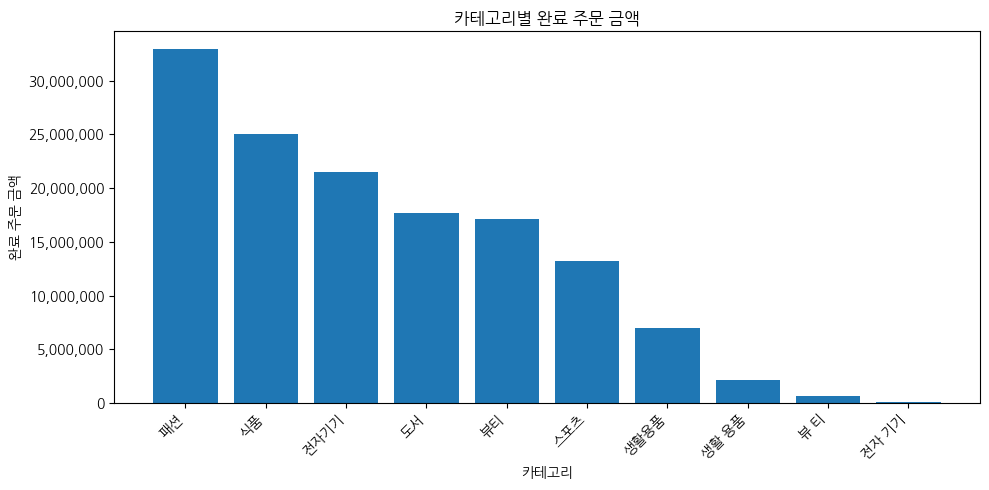

PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_category_completed_amount_bar.png')

In [5]:
category_path = plot_category_sales(
    category_sales,
    FIGURE_DIR / "ch07_category_completed_amount_bar.png",
    show=True,
)
category_path

### 대표 그래프 1 — 카테고리별 완료 주문 금액

![대표 그래프 1](images/graph01.png)

### 원본 집계값

`category_sales` 집계표 기준 완료 주문 금액(내림차순): 패션 32,940,000원(23.99%), 식품 25,035,000원(18.23%), 전자기기 21,485,000원(15.65%), 도서 17,663,000원(12.86%), 뷰티 17,103,000원(12.45%), 스포츠 13,237,000원(9.64%), 생활용품 7,001,000원(5.10%), 생활 용품 2,108,000원(1.54%), 뷰 티 648,000원(0.47%), 전자 기기 105,000원(0.08%). 전체 합계는 137,325,000원이며, `visualization_validation`에서 category/product/customer 세 가지 집계 방식으로 계산해도 모두 동일한 값으로 일치하는 것을 확인했습니다.

### 결과 관찰

완료 주문 금액 기준 상위 카테고리는 패션 → 식품 → 전자기기 순이었고, 정상 표기 기준 가장 낮은 생활용품과는 4배 이상 차이가 났습니다. 또한 `생활 용품`, `뷰 티`, `전자 기기`처럼 띄어쓰기만 다른 카테고리 값이 별도 항목으로 집계되어 있는 것도 함께 확인했습니다.

### 나의 해석과 판단

패션·식품·전자기기 세 카테고리가 전체 완료 주문 금액의 약 58%를 차지해, 매출이 일부 카테고리에 상당히 쏠려 있는 것으로 보입니다.

### 업무·분석적 의미

매출 비중이 높은 상위 3개 카테고리를 재고·프로모션 우선순위 결정에 참고할 수 있습니다. 다만 카테고리 표기가 정리되지 않은 상태(같은 카테고리가 여러 항목으로 쪼개져 집계됨)로 바로 의사결정에 쓰면 하위 카테고리(생활용품, 뷰티, 전자기기)의 실제 비중이 과소평가될 위험이 있어, 표기 정규화가 선행되어야 신뢰할 수 있는 우선순위가 나옵니다.

### 한계와 추가 확인 사항

금액이 크다는 사실만으로 그 카테고리를 더 선호한다거나 수익성이 좋다고 말할 수 없습니다. 판매 수량·상품 수·평균 단가를 함께 봐야 하고, 카테고리 표기 불일치가 정리되지 않은 상태라 정확한 순위는 아직 확정적이지 않습니다. 다음으로는 카테고리 표기를 정규화한 뒤에도 순위가 유지되는지, 판매 수량과 평균 단가를 나눠서 봤을 때도 패션이 1위인지 확인이 필요합니다.

## 4. 월별 완료 주문 금액 — 선그래프

시간 순서가 핵심인 질문이므로 선그래프를 사용합니다. 첫 달과 마지막 달이 완전한 한 달인지, 중간 월이 비어 있다면 실제 0인지 데이터 누락인지 확인합니다.

In [6]:
from src.visualization import plot_monthly_sales

monthly_sales[
    [
        "order_month",
        "completed_amount",
        "completed_order_count",
        "average_completed_order_amount",
    ]
]

,order_month,completed_amount,completed_order_count,average_completed_order_amount
0,2025-07,9479000.0,11,861727.0
1,2025-08,8892000.0,17,523059.0
2,2025-09,4519000.0,4,1129750.0
3,2025-10,12547000.0,17,738059.0
4,2025-11,9163000.0,16,572688.0
5,2025-12,8113000.0,12,676083.0
6,2026-01,8135000.0,9,903889.0
7,2026-02,7689000.0,12,640750.0
8,2026-03,7107000.0,13,546692.0
9,2026-04,11459000.0,14,818500.0


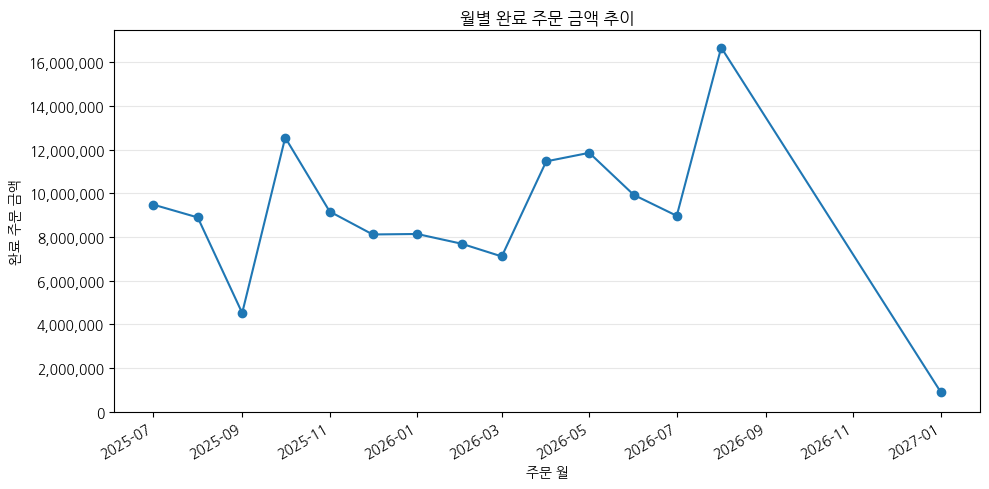

PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_monthly_completed_amount_line.png')

In [7]:
monthly_path = plot_monthly_sales(
    monthly_sales,
    FIGURE_DIR / "ch07_monthly_completed_amount_line.png",
    show=True,
)
monthly_path

### 대표 그래프 2 — 월별 완료 주문 금액

![대표 그래프 2](images/graph02.png)

### 원본 집계값

`monthly_sales` 집계표 기준 2025-07~2026-08까지는 매달 값이 존재하며 4,519,000원(2025-09)~16,668,000원(2026-08) 사이입니다. 이후 2026-09~12는 표에 나타나지 않고 2027-01(909,000원, 1건)로 이어집니다. 날짜가 결측인 완료 주문 상세 6건은 이 집계에서 제외했습니다(전체 검증 기준값 135,422,000원과 일치 확인).

### 결과 관찰

2025-07부터 2026-08까지는 매달 완료 주문 금액이 존재하며 오르내림을 반복합니다. 2026-08 다음에는 2026-09~12 네 달이 표에 아예 나타나지 않고 바로 2027-01로 건너뜁니다.

### 나의 해석과 판단

2026-08이 지금까지 중 가장 높은 완료 주문 금액(16,668,000원, 15건)을 기록했고, 그 이후 관측치가 끊겼습니다. 2027-01은 주문 1건·909,000원뿐이라 한 달 전체가 아니라 데이터가 아직 다 쌓이지 않은 부분 월일 가능성이 높습니다.

### 업무·분석적 의미

월별 추이만 보면 2026-08까지는 성장하는 흐름으로 보이지만, 뒤이은 공백 구간 때문에 "최근 추세가 상승/하락"이라고 업무에 바로 보고하면 안 됩니다. 데이터 수집 상태를 먼저 확인한 뒤에 최신 월 실적을 판단해야 합니다.

### 한계와 추가 확인 사항

2026-09~12가 실제로 주문이 0건이었는지, 데이터 자체가 수집되지 않은 것인지는 이 그래프만으로 구분할 수 없습니다. `monthly_sales`는 groupby로 만들어져 완료 주문이 아예 없는 달은 행 자체가 생성되지 않기 때문입니다. 다음으로는 2026-09~12에 해당하는 원본 주문(`orders`)이 실제로 존재하는지, 존재한다면 상태(취소·환불 등)는 무엇인지, 2027-01을 제외했을 때 추세가 달라지는지 확인이 필요합니다.

## 5. 상품 가격 분포 — 히스토그램

상품 가격은 상품 마스터의 속성이므로 주문 상태와 무관하게 전체 상품을 봅니다. `bins` 값에 따라 모양이 달라질 수 있으므로 구간 수 하나만 보고 이상값을 확정하지 않습니다.

In [8]:
from src.visualization import plot_product_price_hist

products["price"].describe()

count    9.600000e+01
mean     2.048958e+05
std      1.011848e+06
min      5.000000e+03
25%      5.275000e+04
50%      9.450000e+04
75%      1.532500e+05
max      9.999999e+06
Name: price, dtype: float64

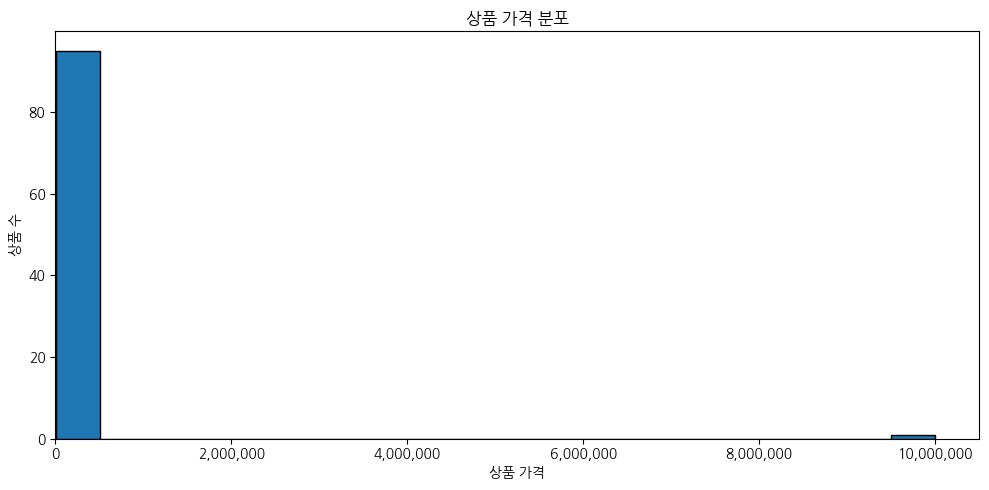

PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_product_price_hist.png')

In [9]:
price_hist_path = plot_product_price_hist(
    products,
    FIGURE_DIR / "ch07_product_price_hist.png",
    show=True,
    bins=20,
)
price_hist_path

### bins 비교 실습

`bins=10`, `20`, `30`으로 바꾸어 같은 데이터가 어떻게 다르게 보이는지 비교합니다.

- 어떤 공통 패턴이 유지되는가?
- 어떤 인상은 bins 선택에 따라 달라지는가?

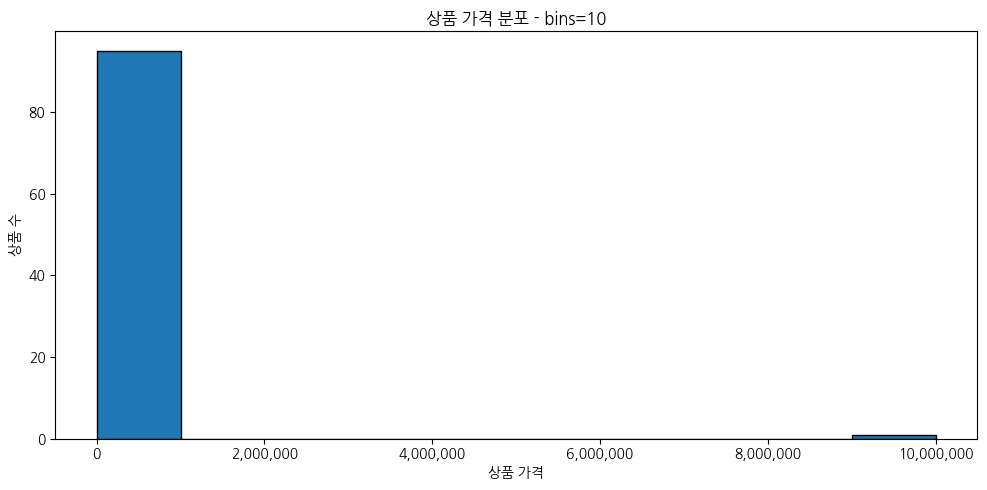

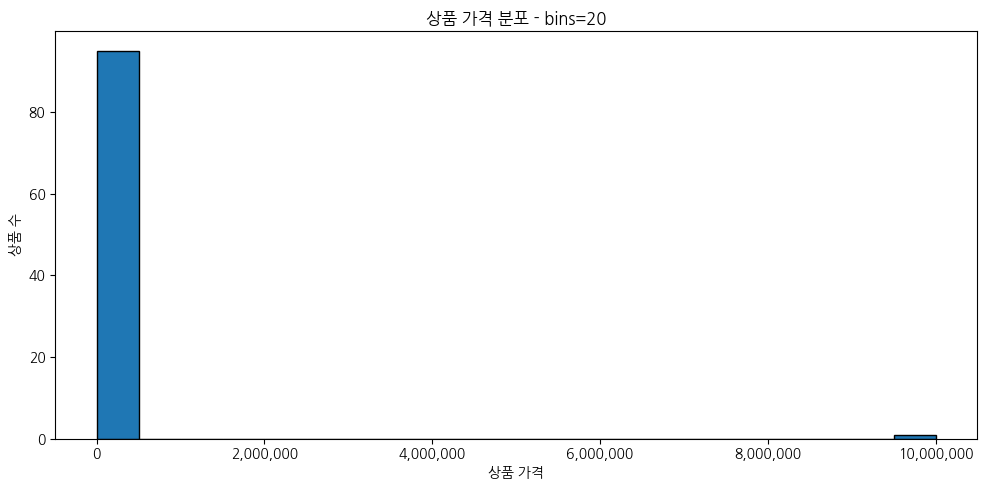

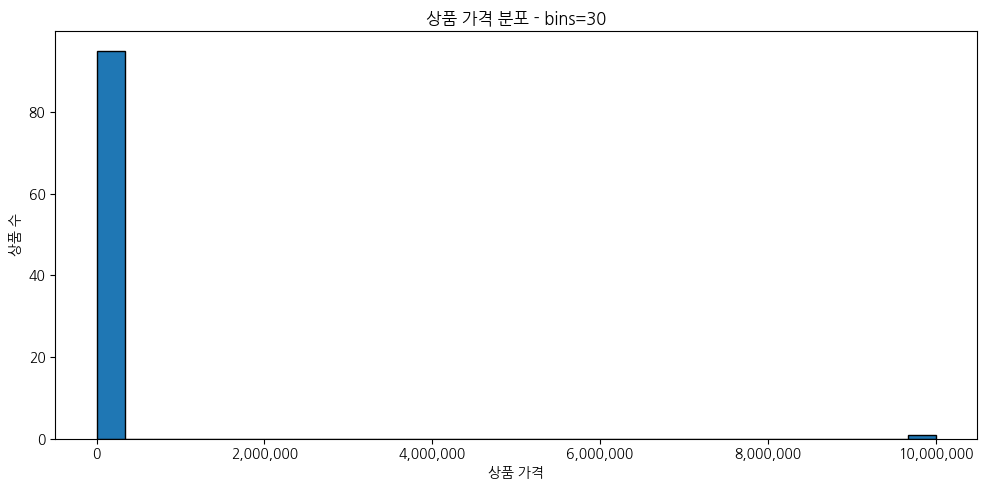

[PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_product_price_hist_bins10.png'),
 PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_product_price_hist_bins20.png'),
 PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_product_price_hist_bins30.png')]

In [10]:
from src.visualization import MONEY_FORMATTER
import matplotlib.pyplot as plt

bins_figure_paths = []
for bins in [10, 20, 30]:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(products["price"].dropna(), bins=bins, edgecolor="black")
    ax.set_title(f"상품 가격 분포 - bins={bins}")
    ax.set_xlabel("상품 가격")
    ax.set_ylabel("상품 수")
    ax.xaxis.set_major_formatter(MONEY_FORMATTER)
    fig.tight_layout()
    out_path = FIGURE_DIR / f"ch07_product_price_hist_bins{bins}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    bins_figure_paths.append(out_path)
    plt.show()

bins_figure_paths

### bins 비교 결과

- 어떤 공통 패턴이 유지되는가: `bins` 값과 관계없이 10만원 미만 구간에 상품이 가장 많이 몰려 있고, 오른쪽으로 긴 꼬리를 가지는 모양은 세 경우 모두 동일하게 유지됩니다.
- 어떤 인상은 bins 선택에 따라 달라지는가: `bins=10`에서는 구간이 넓어 중간 가격대(5만~15만원) 상품이 실제보다 더 고르게 분포한 것처럼 보이지만, `bins=30`으로 늘리면 5만원 이하 구간에 더 세밀하게 몰려 있는 것이 드러납니다. 또한 `describe()`에서 확인한 최댓값 9,999,999원은 나머지 상품 가격(최대 약 20만원대)과 비교했을 때 명백한 이상값 후보이며, bins가 커질수록 이 값이 그래프 오른쪽 끝에 거의 빈 막대로 홀로 떨어져 있는 것이 더 잘 보입니다. 이 값을 임의로 삭제하지 않고 이상값 후보로만 기록해 둡니다.

## 6. 상품 가격과 완료 주문 판매 수량 — 산점도

한 점은 상품 하나입니다. 관계가 보여도 **가격이 판매 수량의 원인**이라고 단정하지 않습니다.

In [11]:
from src.visualization import plot_price_quantity_scatter

product_sales[["price", "completed_quantity", "completed_amount"]].head(10)

,price,completed_quantity,completed_amount
70,183000.0,37.0,6771000.0
90,96000.0,70.0,6720000.0
91,187000.0,26.0,4862000.0
61,193000.0,22.0,4246000.0
50,152000.0,26.0,3952000.0
66,168000.0,21.0,3528000.0
45,171000.0,19.0,3249000.0
36,172000.0,17.0,2924000.0
47,183000.0,15.0,2745000.0
81,145000.0,18.0,2610000.0


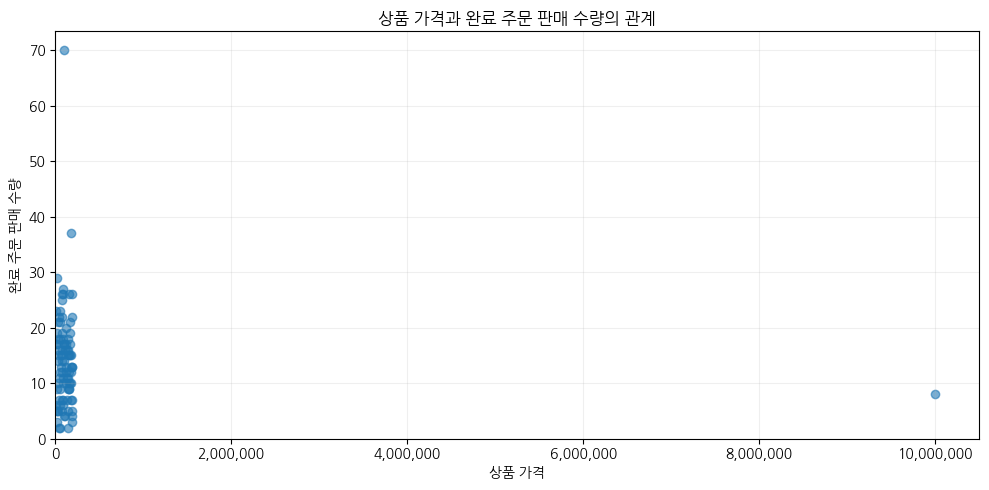

PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_price_completed_quantity_scatter.png')

In [12]:
scatter_path = plot_price_quantity_scatter(
    product_sales,
    FIGURE_DIR / "ch07_price_completed_quantity_scatter.png",
    show=True,
)
scatter_path

### 대표 그래프 3 — 상품 가격과 완료 주문 판매 수량

![대표 그래프 3](images/graph03.png)

### 원본 집계값

`product_sales` 집계표 기준 완료 주문 금액 상위 10개 상품은 가격 96,000원~193,000원, 판매 수량 15개~70개 범위에 있습니다. 1위 상품(가격 183,000원)은 37개 판매로 6,771,000원, 2위 상품(가격 96,000원)은 70개 판매로 6,720,000원을 기록했습니다.

### 결과 관찰

완료 주문 금액 상위 10개 상품은 가격이 특정 구간(10만원 전후)에 몰려 있는 편이고, 판매 수량은 상품마다 편차가 컸습니다. 비슷한 완료 주문 금액을 서로 다른 (가격, 수량) 조합으로 만들어낸 사례가 눈에 띕니다.

### 나의 해석과 판단

가격이 특별히 낮거나 높다고 해서 판매 수량이 일관되게 늘거나 줄어드는 뚜렷한 패턴은 상위 10개 상품만으로는 보이지 않습니다.

### 업무·분석적 의미

가격을 낮춘다고 판매량이 비례해서 늘어난다는 근거로 이 그래프를 쓸 수 없습니다. 가격 정책보다는 상품별 개별 요인(카테고리, 노출, 재고)을 먼저 살펴보는 것이 우선순위가 되어야 합니다.

### 한계와 추가 확인 사항

이 목록은 완료 주문 금액 상위 10개만 본 것이라 전체 96개 상품의 가격-수량 관계를 대표하지 않습니다. 카테고리·할인·재고·노출 순서 같은 다른 변수를 확인하지 않았기 때문에 "가격이 판매 수량의 원인"이라고 말할 수 없습니다. 다음으로는 전체 96개 상품을 카테고리별로 색을 나눠 보면 패턴이 다르게 나타나는지, 가격 이상값(9,999,999원) 상품의 판매 수량은 얼마인지 확인이 필요합니다.

## 7. 완료 주문 구매 금액 상위 고객 — 익명 가로 막대그래프

공개 그래프에서는 고객 이름이나 원본 고객 ID를 직접 표시하지 않고 **순위 기반 익명 라벨**을 사용합니다. Top 10은 전체 고객 분포가 아니라 일부 고객만 보여 줍니다.

In [13]:
from src.visualization import plot_top_customers

customer_sales[
    ["customer_id", "completed_order_count", "completed_amount", "average_completed_order_amount"]
].head(10)

,customer_id,completed_order_count,completed_amount,average_completed_order_amount
1,3,3,6702000.0,2234000.0
7,14,4,5122000.0,1280500.0
57,90,3,4311000.0,1437000.0
47,65,6,3977000.0,662833.0
66,104,2,3966000.0,1983000.0
59,93,4,3845000.0,961250.0
11,20,4,3808000.0,952000.0
27,38,4,3656000.0,914000.0
19,28,4,3201000.0,800250.0
55,85,4,2832000.0,708000.0


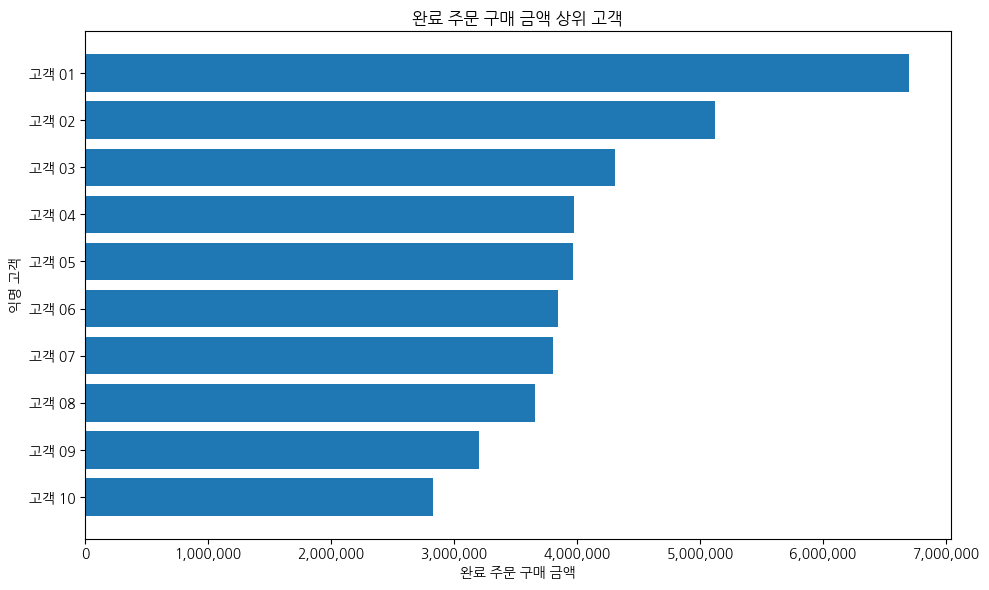

PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_top_customers_anonymized_barh.png')

In [14]:
top_customer_path = plot_top_customers(
    customer_sales,
    FIGURE_DIR / "ch07_top_customers_anonymized_barh.png",
    show=True,
    top_n=10,
)
top_customer_path

### 해석 주의

구매 금액이 높다고 바로 '충성 고객'이라고 부르지 않습니다.

- 반복 주문 횟수는 많은가? → 1위 고객(완료 주문 금액 6,702,000원)은 주문이 3건뿐입니다. 상위 10명의 주문 횟수는 2~6건으로, 반복 구매가 아주 많다고 보기는 어렵습니다.
- 한 번의 큰 주문 때문인가? → 1위 고객의 평균 주문 금액은 2,234,000원으로 상위 10명 중 가장 높습니다. 주문 3건의 평균이 이만큼 크다는 것은 소수의 고액 주문이 순위를 끌어올렸을 가능성을 보여줍니다.
- 평균 주문 금액은 어떤가? → 상위 10명의 평균 주문 금액은 662,833원~2,234,000원으로 편차가 큽니다. 4위 고객은 6건으로 상위 10명 중 주문 횟수가 가장 많지만 평균 주문 금액(662,833원)은 가장 낮은 편입니다.
- 분석 기간이 충분한가? → 월별 데이터가 2025-07~2027-01까지 이어지지만 마지막 구간에 공백과 불완전한 월이 있어(그래프 2 참고), 상위 고객 순위가 특정 시기에 쏠린 결과인지는 추가 확인이 필요합니다.

## 8. 전체 주문 상태 — 막대그래프

이 그래프만 전체 주문을 사용합니다. 상태별 규모는 보여 주지만 취소·환불의 원인을 설명하지 않습니다.

In [15]:
from src.visualization import plot_order_status

order_status

,order_status,order_count
0,completed,180
1,cancelled,63
2,refunded,57


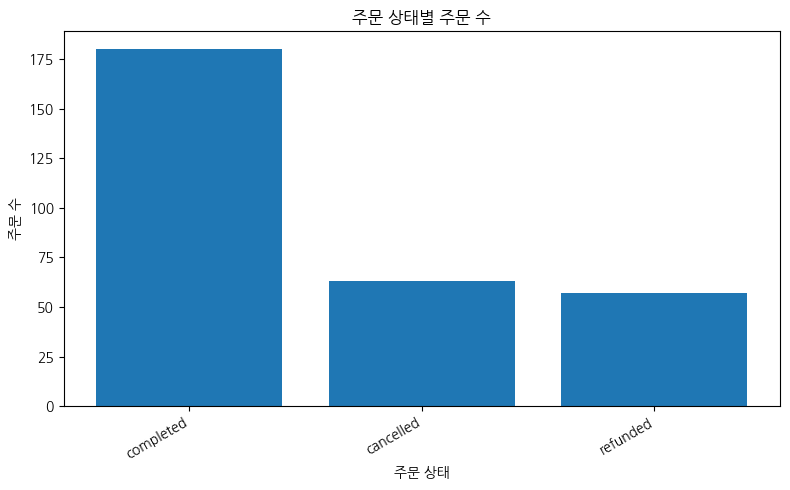

PosixPath('/tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_order_status_bar.png')

In [16]:
order_status_path = plot_order_status(
    order_status,
    FIGURE_DIR / "ch07_order_status_bar.png",
    show=True,
)
order_status_path

## 9. 그래프와 숫자를 교차 검증합니다

대표 그래프 3개 이상에 대해 다음을 확인합니다.

```text
그래프에 표시된 값
=
그래프 원본 집계표의 값
```

또한 다음을 점검합니다.

- 축 이름과 단위가 맞는가?
- 범주 정렬과 날짜 정렬이 맞는가?
- 막대그래프 값 축이 불필요하게 잘리지 않았는가?
- 제목이 실제 분석 범위를 반영하는가?
- 데이터가 없는 구간을 임의로 0으로 만들지 않았는가?

## 그래프 정확성 점검

- [x] 그래프 값과 집계표 값 일치 — 카테고리·월별·고객·상품 집계 합계가 `visualization_validation`에서 모두 `passed=True`로 확인됨 (137,325,000원 기준)
- [x] 축 이름 확인 — 모든 그래프에 x/y축 이름이 한글로 표시됨
- [x] 단위 확인 — 금액 축은 `MONEY_FORMATTER`로 천 단위 구분 표시됨
- [x] 범례 확인 — 이번 6개 그래프는 계열이 1개씩이라 범례가 필요하지 않음 (막대색이 이미 카테고리/상태를 x축 라벨로 표시)
- [x] 날짜 정렬 확인 — 월별 선그래프는 `order_month` 오름차순 정렬 확인
- [x] 과장될 수 있는 축 범위 확인 — 막대·히스토그램·산점도 모두 값 축이 0에서 시작하도록 공통 함수에서 고정됨
- [x] 제목이 분석 범위를 정확히 표현 — "완료 주문 금액", "상품 가격 분포"처럼 범위(completed 여부)가 제목에 드러남

### 내가 발견한 시각화 위험 또는 개선점

- 카테고리 표기 불일치: `생활용품`과 `생활 용품`, `뷰티`와 `뷰 티`, `전자기기`와 `전자 기기`가 서로 다른 카테고리로 집계되어 막대그래프에 별도 막대로 나타납니다. 표기를 정규화하지 않으면 카테고리별 순위를 과소/과대평가할 수 있습니다.
- 월별 선그래프의 데이터 공백: 2026-09~12가 그래프에 아예 나타나지 않아, 이 구간을 못 보고 지나치면 "매달 꾸준히 존재하는 데이터"로 착각할 수 있습니다.
- 상품 가격 히스토그램의 이상값: 가격 9,999,999원인 상품이 있어 x축 범위가 이 값 때문에 과도하게 넓어질 수 있습니다(임의 삭제하지 않고 이상값 후보로만 기록).
- 시각화 이전 단계에서 `order_items_clean.csv`의 FK 미매칭 28개 행(전체의 3.7%)을 발견해 별도 파일로 제외하고 기록했습니다.

## 10. 공통 함수로 전체 그래프와 보고서를 다시 생성합니다

Notebook에서 개별 그래프를 이해한 뒤 공통 함수를 사용해 같은 결과를 재현합니다.

In [17]:
from src.visualization import (
    build_visualization_report,
    create_all_figures,
    create_visualization_summary,
)

saved_figures = create_all_figures(viz_data, FIGURE_DIR, show=False)
summary = create_visualization_summary()

summary_path = REPORT_DIR / "ch07_visualization_summary.md"
summary_path.write_text(
    build_visualization_report(summary),
    encoding="utf-8",
)

print("생성 파일")
for path in saved_figures:
    print("-", path)

print("요약 보고서:", summary_path)
summary

생성 파일
- /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_category_completed_amount_bar.png
- /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_monthly_completed_amount_line.png
- /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_product_price_hist.png
- /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_price_completed_quantity_scatter.png
- /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_top_customers_anonymized_barh.png
- /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/figures/ch07_order_status_bar.png
요약 보고서: /tmp/claude-0/-home-claude/923251ce-6b81-59d8-ad93-2ad5812fb312/scratchpad/ch07work/project/reports/ch07_visualiz

,chart,question,scope,interpretation_point,file_name
0,카테고리별 완료 주문 금액,카테고리별 완료 주문 금액은 어떻게 다른가?,completed orders,금액 차이는 수량·단가 등 추가 지표로 확인,ch07_category_completed_amount_bar.png
1,월별 완료 주문 금액,월별 완료 주문 금액은 어떻게 변하는가?,completed orders + valid order_date,증감은 관찰이며 원인은 추가 데이터 필요,ch07_monthly_completed_amount_line.png
2,상품 가격 분포,상품 가격은 어떤 구간에 몰려 있는가?,product master,상품 구성 분포이며 판매 선호를 의미하지 않음,ch07_product_price_hist.png
3,상품 가격과 완료 주문 판매 수량,상품 가격과 완료 주문 판매 수량은 어떤 패턴을 보이는가?,completed orders aggregated by product,관계는 인과를 의미하지 않음,ch07_price_completed_quantity_scatter.png
4,완료 주문 구매 금액 상위 고객,완료 주문 구매 금액 상위 고객군은 어떻게 구성되는가?,completed orders aggregated by customer,Top N이며 충성도를 자동 의미하지 않음,ch07_top_customers_anonymized_barh.png
5,주문 상태별 주문 수,주문 상태별 주문 수는 어떻게 다른가?,all orders,상태 분포만으로 취소·환불 원인을 알 수 없음,ch07_order_status_bar.png


## 11. Chapter 07 최종 판단

아래 내용을 직접 작성합니다.

### 가장 중요한 그래프 1개와 이유

카테고리별 완료 주문 금액 막대그래프(그래프 1)를 가장 중요하게 봤습니다. 매출이 특정 카테고리(패션·식품·전자기기)에 집중되어 있다는 사실은 이후 재고·마케팅 의사결정과 바로 연결될 수 있는 정보이고, 이 그래프를 만드는 과정에서 카테고리 표기 불일치(띄어쓰기 차이)라는 데이터 품질 문제까지 함께 드러났기 때문입니다.

### 그래프에서 직접 확인한 사실

- 완료 주문 금액 합계는 137,325,000원이며, category/product/customer 세 가지 집계 방식으로 나눠 합산해도 모두 동일한 값으로 일치했습니다(교차 검증 PASS).
- 패션·식품·전자기기 3개 카테고리가 전체 완료 주문 금액의 약 58%를 차지합니다.
- 월별 완료 주문 금액은 2025-07~2026-08까지는 매달 존재하지만 2026-09~12는 표에 나타나지 않고 2027-01로 건너뜁니다.
- 상품 가격 분포는 10만원 미만에 몰려 있고, 9,999,999원이라는 명백한 이상값 후보가 존재합니다.
- 주문 상태는 completed 180건(60%), cancelled 63건(21%), refunded 57건(19%)입니다.

### 이 그래프만으로 말할 수 없는 것

- 카테고리별 금액 차이가 실제 고객 선호나 수익성 차이를 의미하는지는 알 수 없습니다(판매 수량·원가·마진 정보 없음).
- 월별 그래프의 공백 구간(2026-09~12)이 실제 주문 0건인지, 데이터 미수집인지 이 그래프만으로 구분할 수 없습니다.
- 가격과 판매 수량의 관계, 상위 고객의 구매 패턴 모두 다른 변수(카테고리, 프로모션, 재고 등)를 통제하지 않은 상태이므로 인과관계로 해석할 수 없습니다.

### 오해를 줄이기 위해 수정하거나 확인한 요소
- 축: 막대그래프·히스토그램·산점도 모두 값 축을 0에서 시작하도록 공통 함수에서 이미 고정되어 있는 것을 확인했습니다.
- 단위: 금액 축에 천 단위 구분 포맷(`MONEY_FORMATTER`)이 적용된 것을 확인했습니다.
- 정렬: 카테고리는 금액 내림차순, 월별은 시간 순서로 정렬되어 있는 것을 확인했습니다.
- 범위: 금액성 그래프는 `completed` 주문만, 가격 히스토그램은 전체 상품 마스터, 주문 상태 그래프는 전체 주문을 사용한다는 범위 차이를 각 그래프 설명에 명시했습니다.
- 개인정보: 상위 고객 그래프는 실제 고객 ID 대신 "고객 01"~"고객 10" 형태의 익명 라벨만 사용하는 것을 코드에서 확인했습니다.
- (추가) 시각화 전 단계에서 `order_items_clean.csv`의 FK 미매칭 28개 행을 발견해 별도 파일로 제외하고 기록했습니다.

### 다음 분석에서 확인하고 싶은 질문

- 카테고리 표기(띄어쓰기 차이)를 정규화하면 카테고리 순위가 실제로 바뀌는가?
- 2026-09~12 월별 데이터 공백의 원인은 무엇인가(수집 누락 vs 실제 0건)?
- `products_clean.csv`에서 누락되었던 4개 상품(18, 48, 73, 95)을 복구하면 카테고리별·상품별 집계가 어떻게 달라지는가?

---

## 완료 체크

- [x] 질문을 그래프보다 먼저 정했습니다.
- [x] 금액성 그래프에 `completed` 주문 범위를 적용했습니다.
- [x] 집계 검증표의 `passed`를 확인했습니다.
- [x] 대표 그래프 3개 이상을 만들었습니다.
- [x] 그래프와 원본 집계값을 교차 확인했습니다.
- [x] 축·단위·정렬·범위를 확인했습니다.
- [x] 관계를 원인으로 단정하지 않았습니다.
- [x] 고객 그래프에서 개인정보를 직접 노출하지 않았습니다.
- [x] 그래프별 관찰·해석·한계·다음 질문을 작성했습니다.
- [x] `reports/figures`와 요약 보고서가 재생성되는지 확인했습니다.

다음 Chapter 08에서는 전처리, EDA, 시각화와 보고서를 하나의 작은 분석 프로젝트로 연결합니다.

## 최종 체크 (답안 양식 기준)

- [x] 그래프와 수치를 교차 검증했습니다.
- [x] 관찰과 해석을 구분했습니다.
- [x] 업무적 의미와 한계를 작성했습니다.
- [ ] 최종 Notebook URL을 제출합니다. (GitHub push 후 LMS에 제출)